In [1]:
import numpy as np 
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb

In [2]:
ROOT = Path('results')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [3]:
scale_cut = [1, 5]
data = np.load(f"{ROOT}/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_v4.npz")
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']
print(data.files)

['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


In [4]:
tomo = 4
z = [data[f'{tomo}/{name}_z'] for name in names]
npz = [data[f'{tomo}/{name}'] for name in names]
npz_err = [data[f'{tomo}/{name}_err'] for name in names]

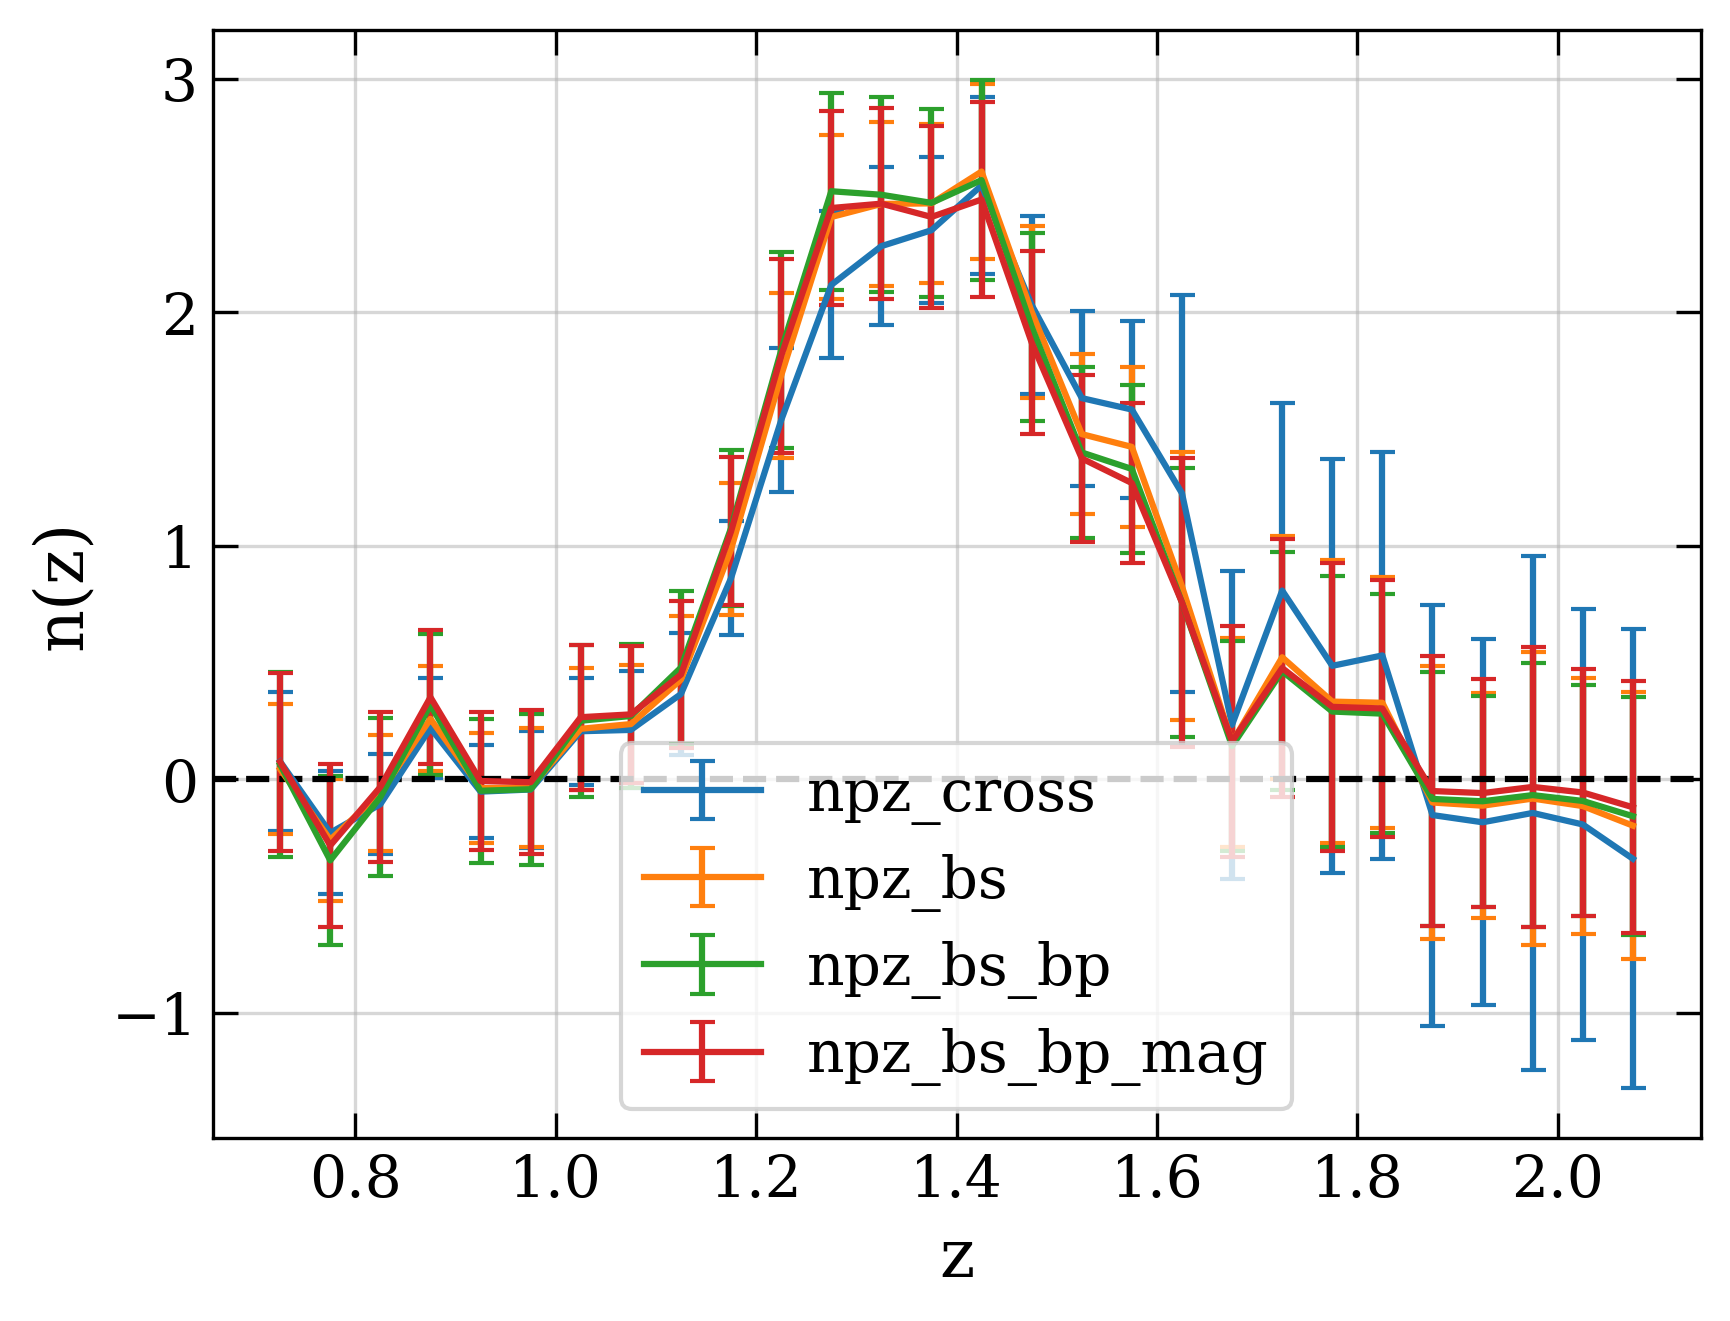

In [5]:
for i, name in enumerate(names):
    plt.errorbar(z[i], npz[i], npz_err[i], capsize=3, label=name)
plt.legend()
plt.grid(True)
plt.ylabel('n(z)')
plt.xlabel('z')
plt.axhline(0, color='black', linestyle='--')

In [7]:
dir_splines = Path(f'results/splines_{scale_cut[0]}_{scale_cut[1]}_v5')
if not dir_splines.exists():
    dir_splines.mkdir(parents=True)
for i, name in enumerate(names):
    for tomo in range(1, 5):
        savefile = str(dir_splines / f'spl_{name}_{tomo}')
        if Path(f'{savefile}.nc').exists():
            print(f'Skipping {savefile}, already exists')
            continue
        npz_arr = data[f'{tomo}/{name}']
        npz_arr_err = data[f'{tomo}/{name}_err']   
        z = data[f'{tomo}/{name}_z'] 
        spl = spline.BayesianBSpline(zv=z, n_knots=int(len(z)/1.5))
        spl.fit(npz_arr, npz_arr_err, n_tune=400, n_samples=1600, target_accept=0.99, prior_concentration=3, base_alpha=0.05)
        spl.save_model(savefile)

Skipping results/splines_1_5_v5/spl_npz_cross_1, already exists
Skipping results/splines_1_5_v5/spl_npz_cross_2, already exists
14.74190246712182
Dirichlet alpha range: [0.050, 8.819]
Non-zero NNLS coefficients: 12 / 26
[0.         0.         0.         0.         0.         0.41520863
 0.         0.         0.74907719 1.77210757 2.46761253 2.92300276
 1.25469692 1.67144228 0.         1.03201014 0.03776389 0.68244878
 0.34770769 0.         1.38882407 0.         0.         0.
 0.         0.        ]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 400 tune and 1_600 draw iterations (1_600 + 6_400 draws total) took 90 seconds.


Model fitting complete. Summary:               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]    0.000  0.002   0.000    0.002      0.000    0.000    1367.0   
coeffs[1]    0.001  0.003   0.000    0.004      0.000    0.000    1690.0   
coeffs[2]    0.001  0.003   0.000    0.003      0.000    0.000    1517.0   
coeffs[3]    0.001  0.003   0.000    0.003      0.000    0.000    1268.0   
coeffs[4]    0.001  0.003   0.000    0.003      0.000    0.000    1292.0   
coeffs[5]    0.025  0.018   0.000    0.057      0.000    0.000    5244.0   
coeffs[6]    0.001  0.004   0.000    0.004      0.000    0.000    1248.0   
coeffs[7]    0.001  0.003   0.000    0.003      0.000    0.000    1515.0   
coeffs[8]    0.045  0.019   0.012    0.080      0.000    0.000    6180.0   
coeffs[9]    0.124  0.026   0.076    0.174      0.000    0.000    5702.0   
coeffs[10]   0.169  0.032   0.111    0.232      0.000    0.000    6104.0   
coeffs[11]   0.203  0.033   0.146    0.271      0.000  

...

Model fitting complete. Summary:               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]    0.001  0.004   0.000    0.004      0.000    0.000    1314.0   
coeffs[1]    0.001  0.005   0.000    0.004      0.000    0.000    1394.0   
coeffs[2]    0.001  0.004   0.000    0.004      0.000    0.000    1569.0   
coeffs[3]    0.001  0.004   0.000    0.004      0.000    0.000    1328.0   
coeffs[4]    0.001  0.004   0.000    0.004      0.000    0.000    2461.0   
coeffs[5]    0.028  0.020   0.000    0.064      0.000    0.000    5961.0   
coeffs[6]    0.003  0.007   0.000    0.016      0.000    0.000    1966.0   
coeffs[7]    0.001  0.003   0.000    0.003      0.000    0.000    1529.0   
coeffs[8]    0.064  0.024   0.022    0.109      0.000    0.000    6843.0   
coeffs[9]    0.146  0.032   0.089    0.207      0.000    0.000    6324.0   
coeffs[10]   0.187  0.035   0.119    0.251      0.000    0.000    6273.0   
coeffs[11]   0.206  0.034   0.143    0.270      0.000  

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 400 tune and 1_600 draw iterations (1_600 + 6_400 draws total) took 68 seconds.


Model fitting complete. Summary:               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]    0.004  0.008   0.000    0.018      0.000    0.000    1955.0   
coeffs[1]    0.001  0.004   0.000    0.004      0.000    0.000    1197.0   
coeffs[2]    0.001  0.003   0.000    0.004      0.000    0.000    1245.0   
coeffs[3]    0.016  0.014   0.000    0.041      0.000    0.000    3963.0   
coeffs[4]    0.001  0.003   0.000    0.003      0.000    0.000    1240.0   
coeffs[5]    0.020  0.015   0.000    0.048      0.000    0.000    5270.0   
coeffs[6]    0.015  0.015   0.000    0.042      0.000    0.000    4808.0   
coeffs[7]    0.110  0.030   0.057    0.168      0.000    0.000    7078.0   
coeffs[8]    0.212  0.038   0.141    0.284      0.000    0.000    6386.0   
coeffs[9]    0.176  0.038   0.101    0.246      0.000    0.000    6313.0   
coeffs[10]   0.203  0.037   0.137    0.276      0.000    0.000    6262.0   
coeffs[11]   0.087  0.030   0.028    0.142      0.000  

In [ ]:
spl_study = spl_mag_1
show_knots = True
z_eval = np.linspace(z.min(), z.max(), 200)
n_eval_points=200
nz_samples = spl_study.get_samples(z_eval=z_eval, n_eval_points=n_eval_points)
basis_eval = spl_study._create_evaluation_basis(z_eval)

nz_median = np.percentile(nz_samples, 50, axis=0)
nz_mean = np.mean(nz_samples, axis=0)
nz_std = np.std(nz_samples, axis=0)
nz_lower = np.percentile(nz_samples, 16, axis=0)
nz_upper = np.percentile(nz_samples, 84, axis=0)

fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], hspace=0.3, wspace=0.25)
ax_main = fig.add_subplot(gs[0, :])

info_text = f'Knots: {spl_study.n_knots}\nDegree: {spl_study.degree}\nBasis functions: {spl_study.n_basis}'

ax_main.errorbar(
    spl_study.zv, 
    spl_study.nz, 
    yerr=spl_study.nz_err,
    fmt='o', 
    color='black',
    alpha=0.7,
    capsize=3, 
    capthick=1, 
    label='Data'
    )

if show_knots:
    knot_positions = spl_study.knots[spl_study.degree:-spl_study.degree]
    for i, knot in enumerate(knot_positions):
        alpha_val = 0.6 if i == 0 else 0.4
        label_val = 'Knots' if i == 0 else None
        ax_main.axvline(knot, color='gray', linestyle='--', alpha=alpha_val, 
                    linewidth=1, label=label_val)

ax_main.set_xlabel('Redshift (z)', fontsize=13)
ax_main.set_ylabel('p(z)', fontsize=13)
ax_main.grid(True, alpha=0.3)

ax_main.plot(
    z_eval, 
    nz_median, 
    color='red', 
    alpha=1,
    linewidth=2, 
    label='median'
    )
ax_main.fill_between(
    z_eval, 
    nz_lower, 
    nz_upper, 
    color='red', 
    alpha=0.3, 
    label='1σ'
    )

ax_main.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax_main.text(
    0.02, 
    0.98, 
    info_text, 
    transform=ax_main.transAxes,
    verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), 
    fontsize=12
    )
ax_main.set_xlim(0.35, 1.15)

ax_basis = fig.add_subplot(gs[1, 0])
n_show = spl_study.n_basis
indices = np.linspace(1, spl_study.n_basis, n_show, dtype=int)
colors = plt.cm.plasma(np.linspace(0, 1, n_show))

for i, idx in enumerate(indices):
    basis_func = basis_eval[:, i]
    ax_basis.plot(
        z_eval, 
        basis_func, 
        color=colors[i], 
        alpha=0.7, 
        linewidth=1.5, 
        label=f'B_{idx}' if n_show <= 6 else None
        )

ax_basis.set_xlabel('Redshift (z)', fontsize=12)
ax_basis.set_ylabel('Basis amplitude', fontsize=12)
ax_basis.set_title(f'B-spline Basis Functions (showing {n_show}/{spl_study.n_basis})', fontsize=12)
ax_basis.grid(True, alpha=0.3)
if n_show <= 6:
    ax_basis.legend(fontsize=9, ncol=2)

# Coefficient histogram (bottom right)
ax_coeff = fig.add_subplot(gs[1, 1])
coeff_means = np.mean(spl_study.coeffs_samples, axis=0)
coeff_stds = np.std(spl_study.coeffs_samples, axis=0)
coeff_medians = np.median(spl_study.coeffs_samples, axis=0)
x_pos = np.arange(spl_study.n_basis)

ax_coeff.bar(x_pos, coeff_medians, yerr=coeff_stds, 
                    capsize=2, alpha=0.7, color='steelblue',
                    edgecolor='darkblue', linewidth=0.5, error_kw={'linewidth': 1})

ax_coeff.scatter(x_pos, coeff_medians, color='red', s=15, alpha=0.8, 
                zorder=3, label='Median')

ax_coeff.set_xlabel('Basis Function Index', fontsize=12)
ax_coeff.set_ylabel('Coefficient Value', fontsize=12)
ax_coeff.set_title('Posterior Coefficient Distribution', fontsize=12)
ax_coeff.grid(True, alpha=0.3, axis='y')
ax_coeff.legend(fontsize=10)
ax_coeff.set_xlim(3+.5, 17+0.5)
ax_coeff.set_xticks([])

plt.tight_layout()

In [8]:
tomo_bin_dnnz = np.loadtxt('pz/data/tomographic_binning_dnnz.dat')
mids = tomo_bin_dnnz[:, 0]

In [9]:
scale_cut = [1, 5]
splines_dict = {name : {tomo : spline.BayesianBSpline.from_saved_model(f'results/splines_{scale_cut[0]}_{scale_cut[1]}_v4/spl_{name}_{tomo}') for tomo in [1,2,3,4]} for name in names}

bounds = {
    '1' : (0, 0.9),
    '2' : (0.3, 1.3),
    '3' : (0.5, 2.1),
    '4' : (0.7, 2.1)
}
do_bounds = True
if not do_bounds:
    bounds = {
        f'{i}' : (0, 3) for i in range(1, 5)
    }

9.781818997052472
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_1_5_v4/spl_npz_cross_1.nc
  - Metadata: results/splines_1_5_v4/spl_npz_cross_1_meta.pkl
  - Posterior samples: 6400
9.900485526637631
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_1_5_v4/spl_npz_cross_2.nc
  - Metadata: results/splines_1_5_v4/spl_npz_cross_2_meta.pkl
  - Posterior samples: 6400
10.885691513586897
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_1_5_v4/spl_npz_cross_3.nc
  - Metadata: results/splines_1_5_v4/spl_npz_cross_3_meta.pkl
  - Posterior samples: 6400
10.169205789614335
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_1_5_v4/spl_npz_cross_4.nc
  - Metadata: results/splines_1_5_v4/spl_npz_cross_4_meta.pkl
  - Posterior samples: 6400
9.864308506301493
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_1_5_v4/spl_npz_bs_1.nc
  - Me

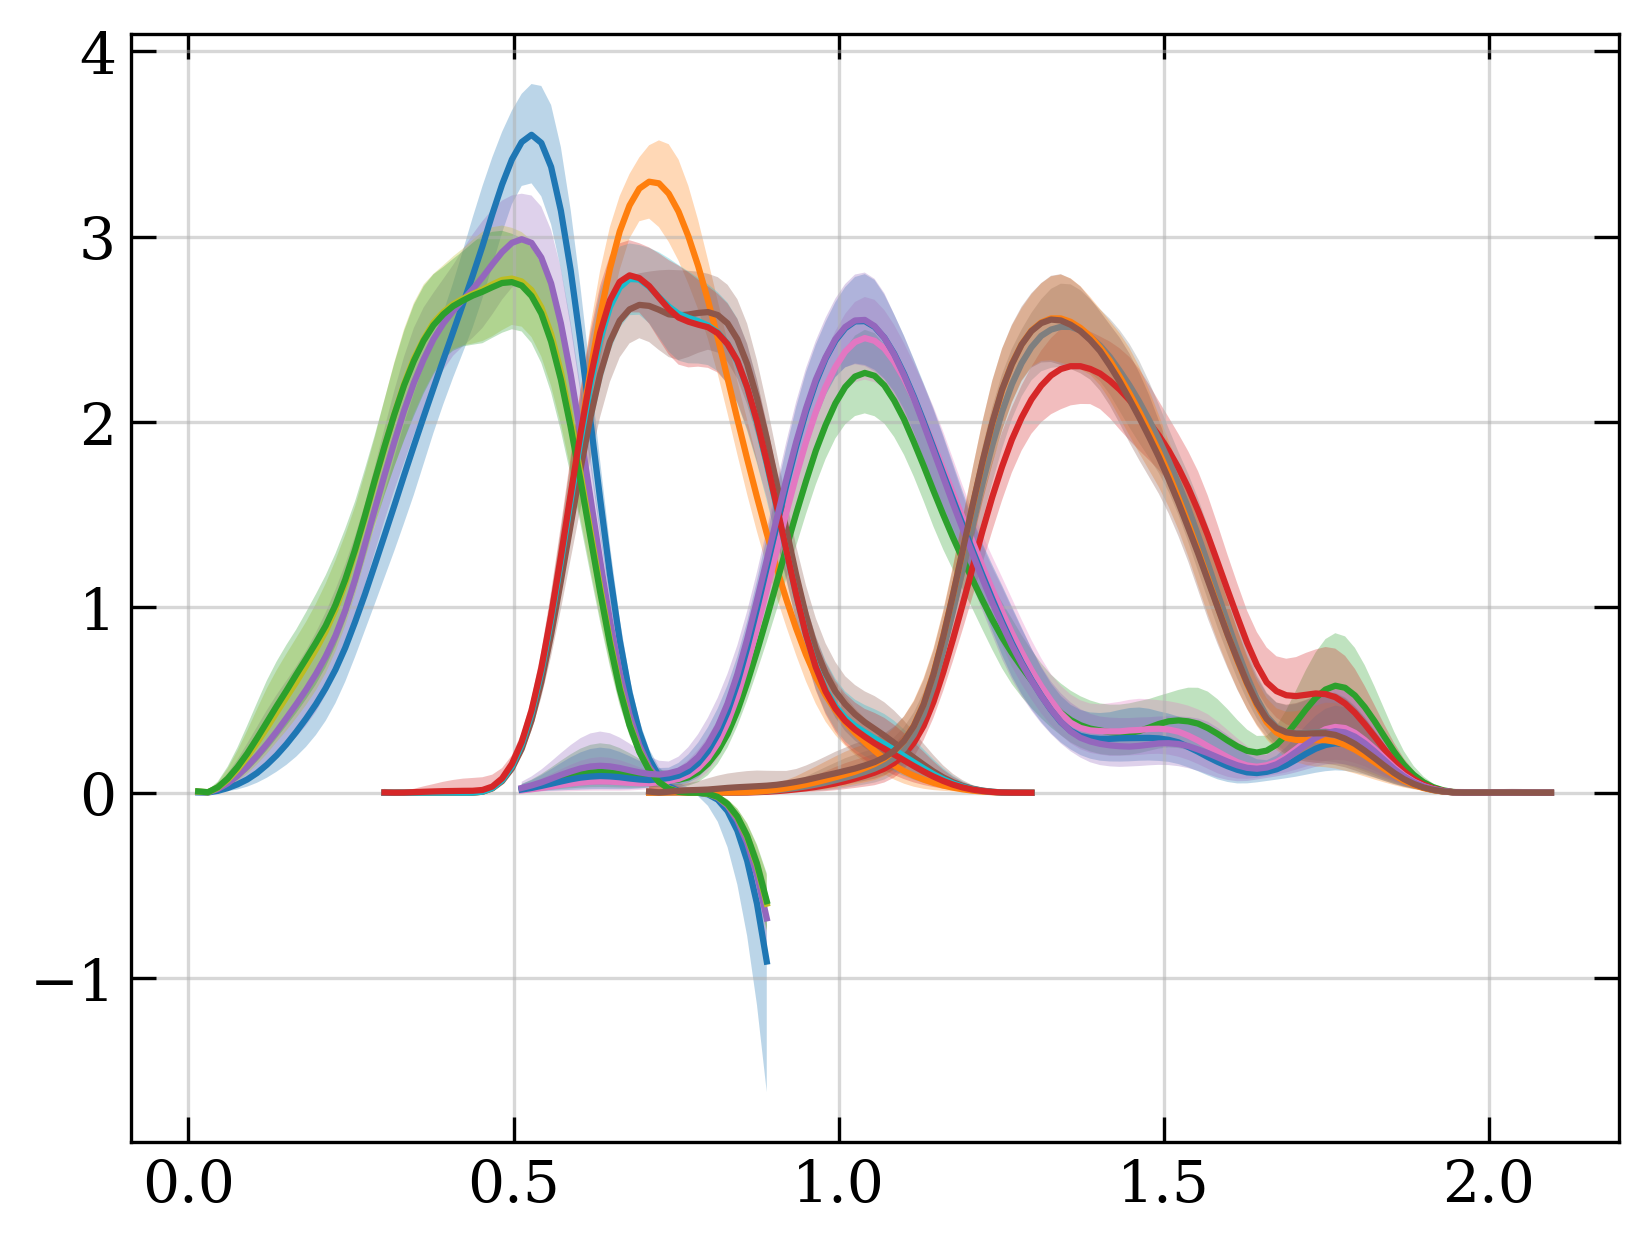

In [10]:
# save to file the sample draws 
for name in ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']:
    for tomo in range(1, 5):
        spl = splines_dict[name][tomo]
        z_eval_full = np.linspace(0, 3, 200)
        basis_eval = spl._create_evaluation_basis(z_eval_full)
        coeffs_samples = spl.coeffs_samples
        amplitude_samples = spl.amplitude_samples
        nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]
        mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
        nz_samples_s = nz_samples_full[:, mask]
        z_eval = z_eval_full[mask]
        
        integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
        nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])

        nz_median = np.percentile(nz_samples, 50, axis=0) / integ
        nz_lower = np.percentile(nz_samples, 16, axis=0) / integ
        nz_upper = np.percentile(nz_samples, 84, axis=0) / integ
        
        plt.plot(z_eval, nz_median, label=f'Tomo {tomo}')
        plt.fill_between(z_eval, nz_lower, nz_upper, alpha=0.3)

In [11]:
with pm.make_plot(
    name=f'all_tomo_sp', show=True,
    figsize=(12, 7), ncols=2, nrows=2,
    sharey=True  # share y-axis
) as (fig, axs):
    axs = axs.flatten()

    for i, tomo in enumerate([1]):
        ax = axs[i]
        ax.grid(True)
        ax.axhline(0, color='black', alpha=0.7, linestyle='--')
        ax.set_xlim(bounds[str(tomo)])

        # --- Only outer labels ---
        if i in [2, 3]:  # bottom row
            ax.set_xlabel("Redshift (z)")
        if i in [0, 2]:  # left column
            ax.set_ylabel("p(z)")

        # --- Phot calibration (dnnz) ---
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
        ax.fill_between(
            mids,
            np.percentile(dnnz, 16, axis=0),
            np.percentile(dnnz, 84, axis=0),
            color='gray',
            hatch='//',
            alpha=0.2,
            label="Phot (16–84%)" if i == 0 else None
        )

        # --- Loop over raw + mag splines ---
        for index, label, splines, color, linestyle in [
            (0, "n(z) (median"+r'$\pm1\sigma$)', splines_dict['npz_bs_bp'], 'blue', '-'),
            (1, "n(z) "+r'$\mu-corr$', splines_dict['npz_bs_bp_mag'], 'red', '--'),
            (2, "n(z) "+r'$b_s$', splines_dict['npz_bs'], 'green', '-.')
        ]:
            spl = splines[tomo-1]
            z_eval_full = np.linspace(0, 3, 200)

            basis_eval = spl._create_evaluation_basis(z_eval_full)
            coeffs_samples = spl.coeffs_samples
            amplitude_samples = spl.amplitude_samples
            nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

            mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
            nz_samples_s = nz_samples_full[:, mask]
            z_eval = z_eval_full[mask]

            nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])
        
            integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
            nz_median = np.percentile(nz_samples, 50, axis=0) / integ
            nz_lower = np.percentile(nz_samples, 16, axis=0) / integ
            nz_upper = np.percentile(nz_samples, 84, axis=0) / integ

            ax.plot(
                z_eval,
                nz_median,
                color=color,
                alpha=1,
                linewidth=1.6,
                linestyle=linestyle
            )
            ax.fill_between(
                z_eval,
                nz_lower,
                nz_upper,
                color=color,
                alpha=0.2,
            )

            # --- Data points ---
            z_data = data[f'{tomo}/z']
            npz_data = data[f'{tomo}/{name}'] #/ integ
            npz_data_err = data[f'{tomo}/{name}_err'] #/ integ
            mask_data = (z_data > bounds[str(tomo)][0]) & (z_data < bounds[str(tomo)][1])

            ax.errorbar(
                z_data[mask_data], 
                npz_data[mask_data],
                yerr=npz_data_err[mask_data],
                fmt='s' if index==0 else 'd',
                color=color,
                capsize=3,
                ms=3.5,
                label=label if i == 0 else None
            )

        # --- Bin label in upper-right ---
        ax.text(
            0.95, 0.95, f"Bin {i+1}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=14, 
        )

    # --- Legend only in first subplot ---
    axs[0].legend(
        loc='upper left',
        frameon=True,
        fontsize=11,
        title=f'Scale : [0.3–3] '+r'h$^{-1}$Mpc',
        title_fontsize=11
    )

KeyError: 0

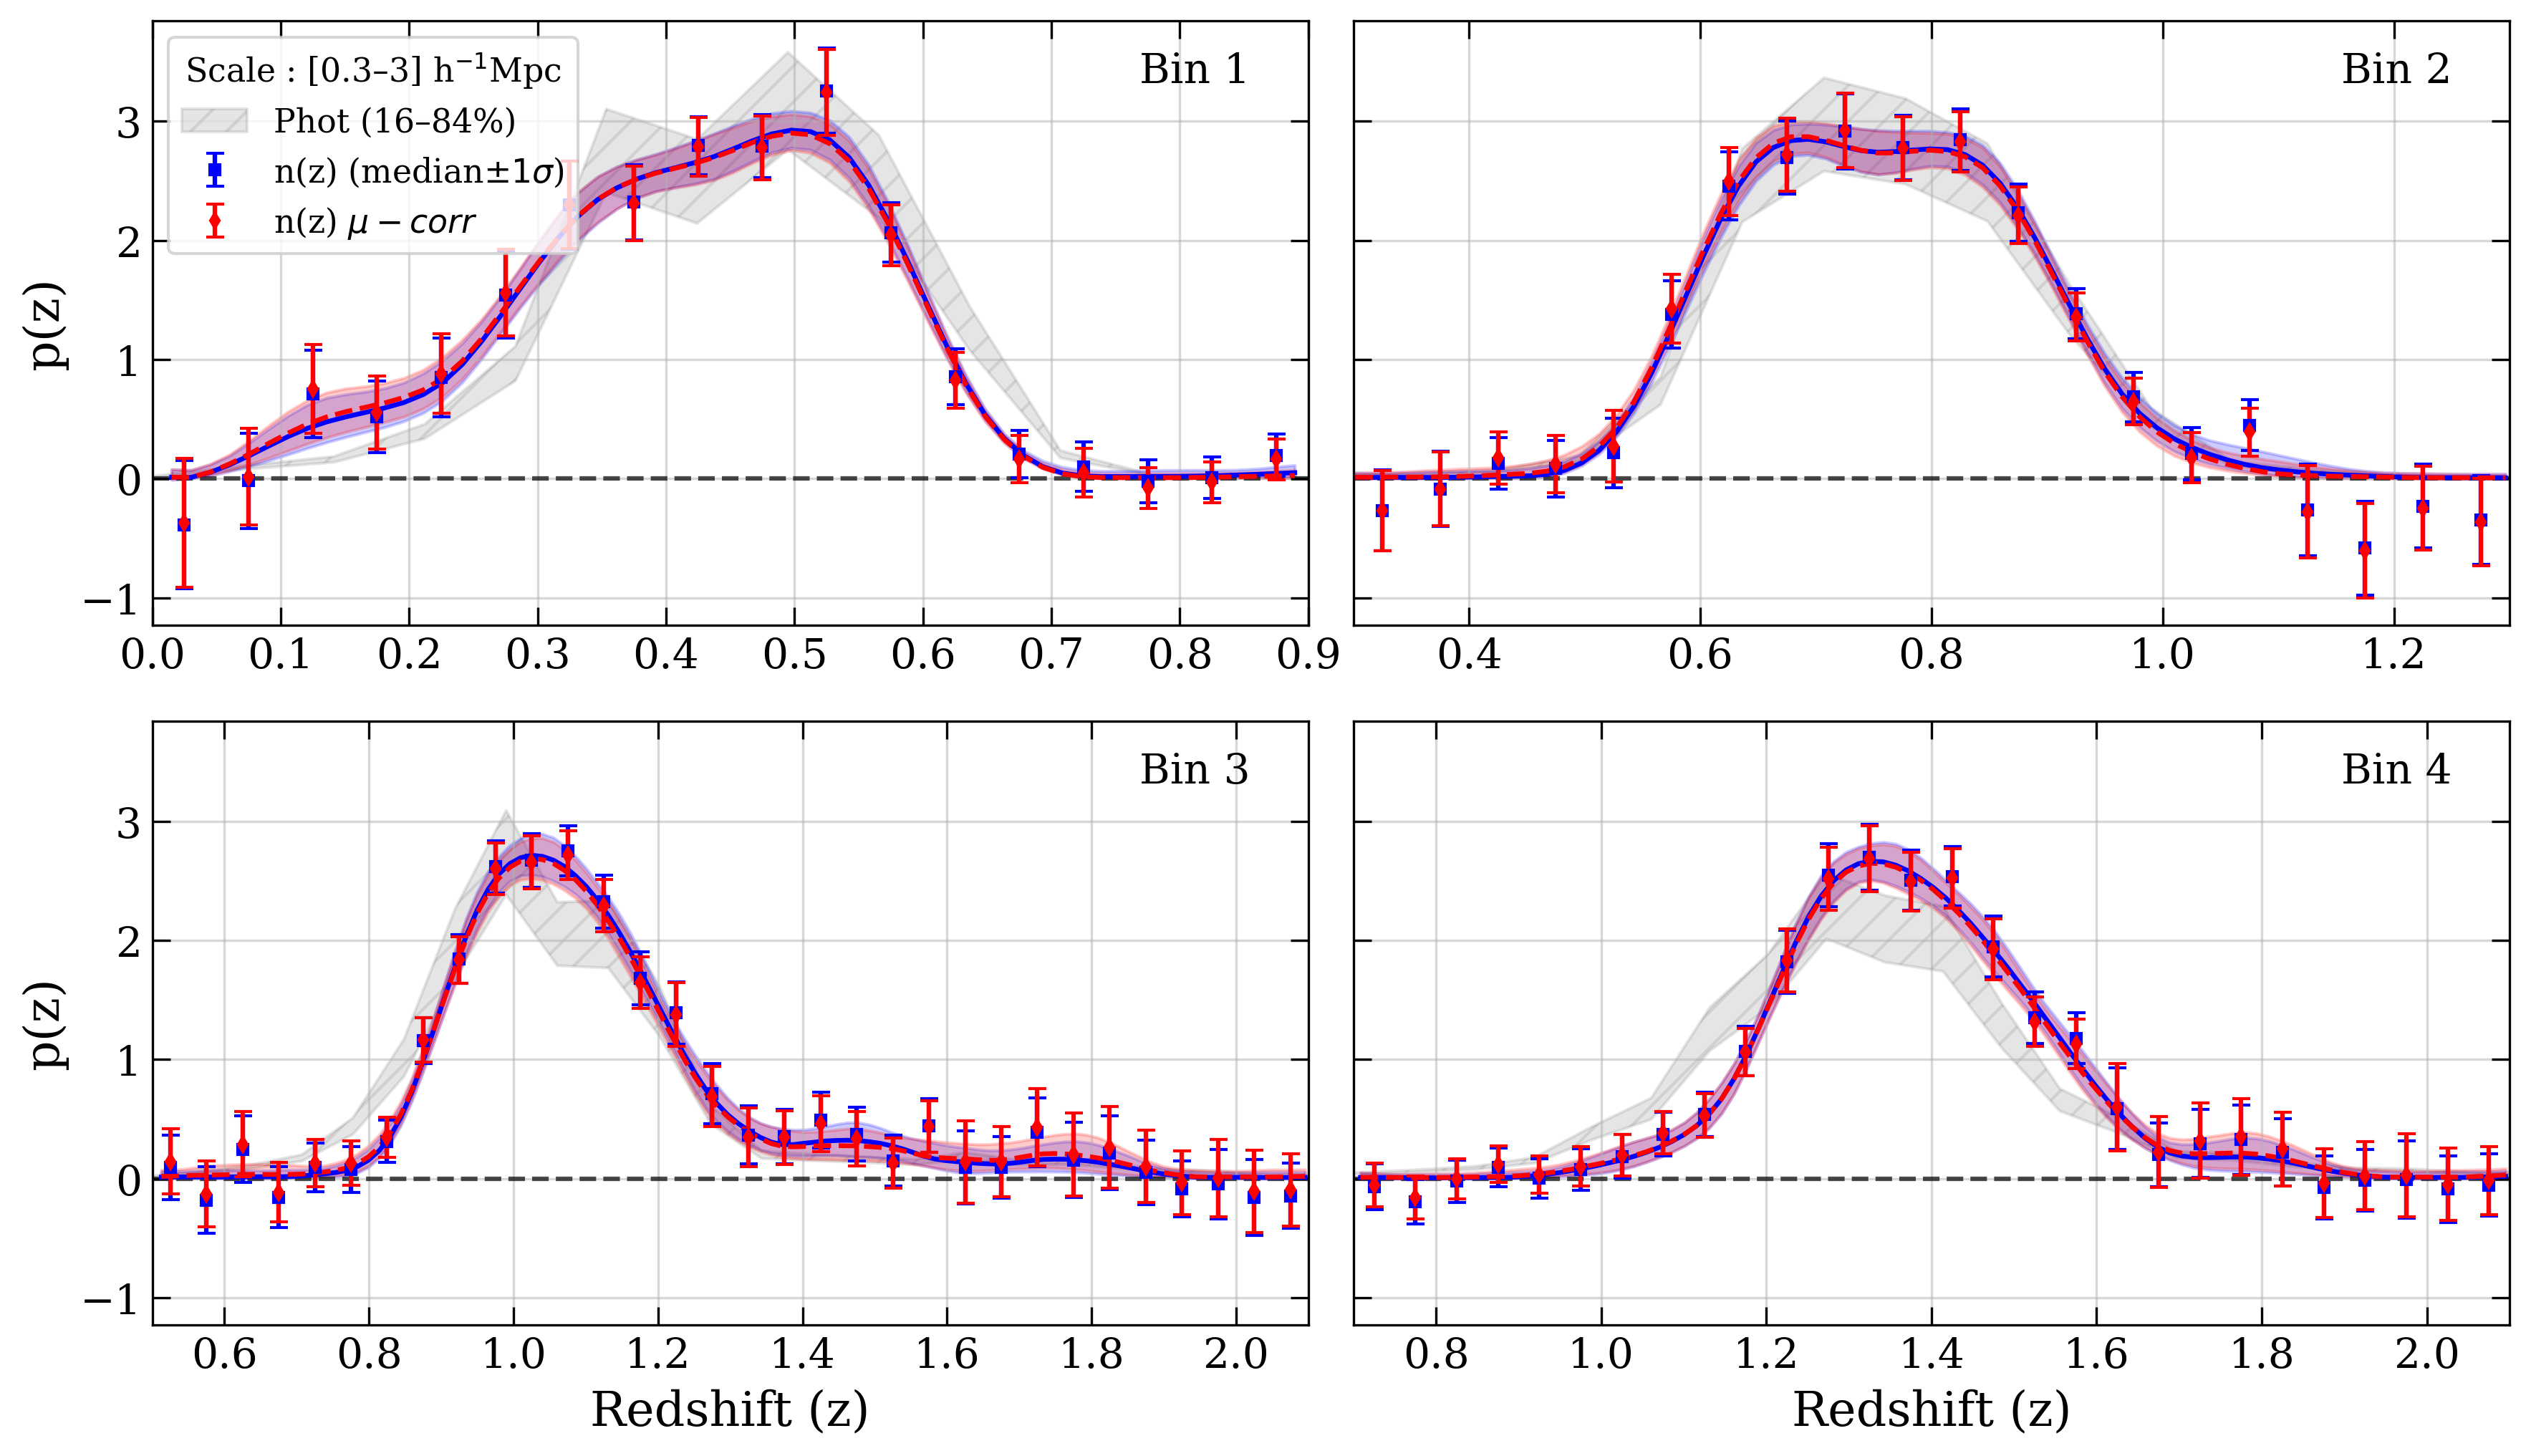](attachment:image.png)

In [11]:

import pandas as pd
splines = splines_tomo_mag
rows = []

for tomo in [1, 2, 3, 4]:
    spl = splines[tomo-1]
    z_eval_full = np.linspace(0, 3, 200)

    basis_eval = spl._create_evaluation_basis(z_eval_full)
    coeffs_samples = spl.coeffs_samples
    amplitude_samples = spl.amplitude_samples
    nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

    # Restrict to bounds
    mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
    nz_samples_s = nz_samples_full[:, mask]
    z_eval = z_eval_full[mask]

    nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])

    nz_median = np.percentile(nz_samples, 50, axis=0) 
    nz_lower  = np.percentile(nz_samples, 16, axis=0) 
    nz_upper  = np.percentile(nz_samples, 84, axis=0) 

    complete_nz_median = np.zeros_like(z_eval_full)
    complete_nz_median[mask] = nz_median
    complete_nz_lower = np.zeros_like(z_eval_full)
    complete_nz_lower[mask] = nz_lower
    complete_nz_upper = np.zeros_like(z_eval_full)
    complete_nz_upper[mask] = nz_upper

    # Each row is one tomo bin, storing full arrays
    rows.append({
        "tomo": tomo,
        "z": z_eval_full,
        "nz_median": complete_nz_median,
        "nz_lower": complete_nz_lower,
        "nz_upper": complete_nz_upper
    })

df = pd.DataFrame(rows)
print(df)
# Save with pyarrow backend (best for lists)
df.to_parquet("nz_splines.parquet", engine="pyarrow", index=False)

   tomo                                                  z  \
0     1  [0.0, 0.01507537688442211, 0.03015075376884422...   
1     2  [0.0, 0.01507537688442211, 0.03015075376884422...   
2     3  [0.0, 0.01507537688442211, 0.03015075376884422...   
3     4  [0.0, 0.01507537688442211, 0.03015075376884422...   

                                           nz_median  \
0  [0.0, 0.01171215072644526, 0.01026380353664578...   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   

                                            nz_lower  \
0  [0.0, -0.008322791767915543, 0.002870093964376...   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   

                                            nz_upper  
0  [0.0, 0.07952243203590857, 0.07119011293039366...  
1  [0.0, 0.0, 0.0

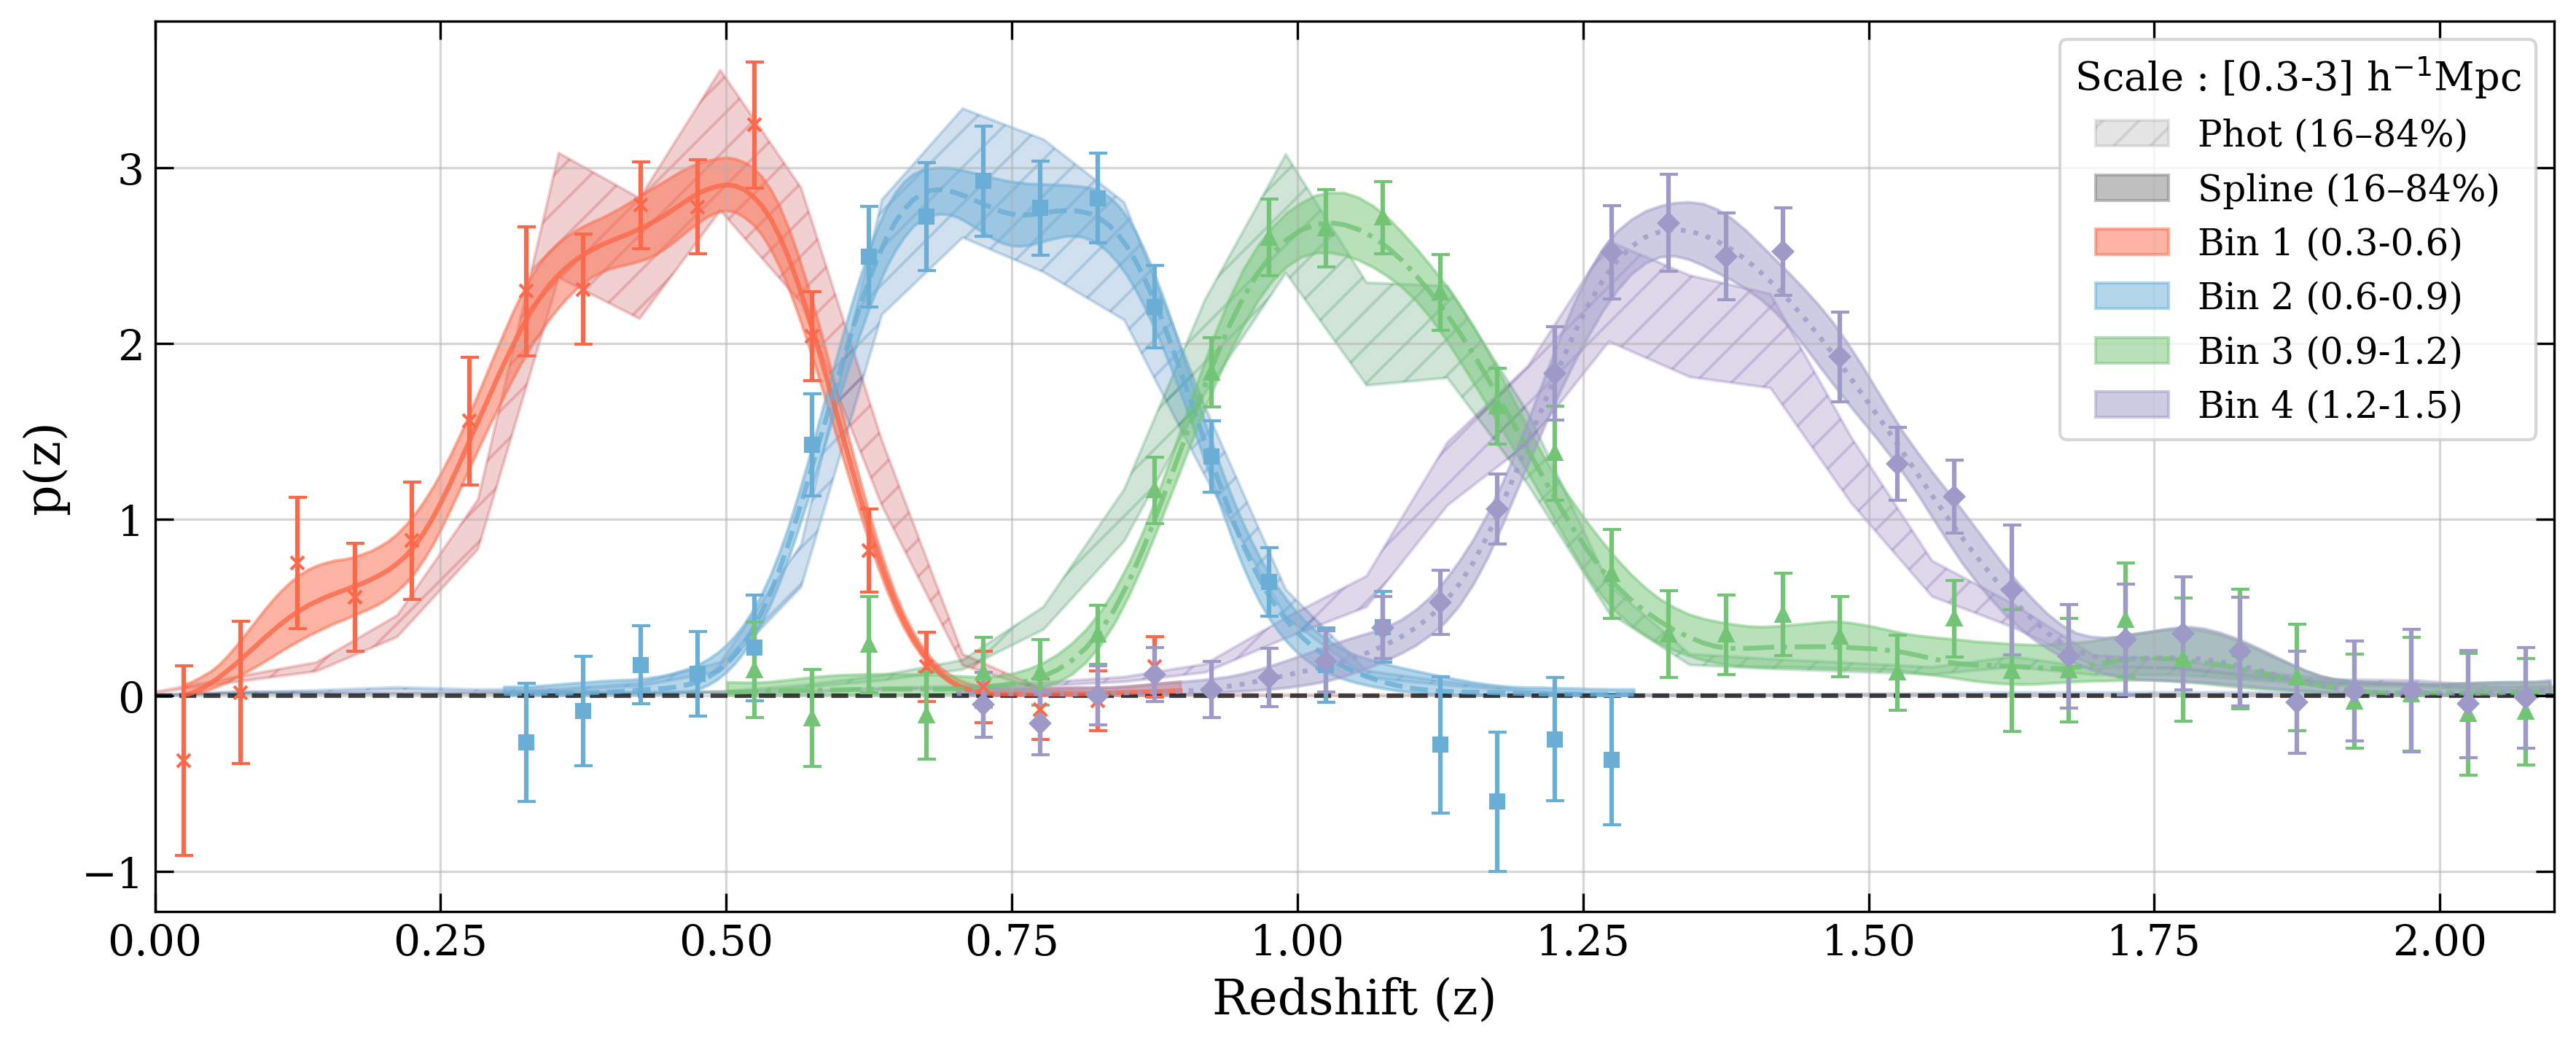

In [82]:
show_dnnz_phot = True

with pm.make_plot(name=f'all_tomo', show=True, figsize=(12, 5)) as (fig, ax):
    #ax.errorbar(z, npz_raw, yerr=npz_raw_err, fmt='d', color='b', capsize=3, label="No mag correction")
    #ax.errorbar(z, npz_mag, yerr=npz_mag_err, fmt='x', color='r', capsize=3, label="With mag correction")
    ax.grid(True)
    ax.axhline(0, color='black', alpha=0.7, linestyle='--')
    ax.set_xlabel("Redshift (z)")
    ax.set_ylabel('p(z)')
    ax.set_xlim(0., 2.1)

    for tomo in [1, 2, 3, 4]:
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[tomo-1](0.8), 
            hatch='//',
            alpha=0.2,
            )

    for tomo, spl in enumerate(splines_tomo_mag, start=1):
        z_eval_full = np.linspace(spl.zv.min(), spl.zv.max(), 200)

        basis_eval = spl._create_evaluation_basis(z_eval_full)
        coeffs_samples = spl.coeffs_samples

        amplitude_samples = spl.amplitude_samples
        nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]
        mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
        nz_samples_s = nz_samples_full[:, mask]
        z_eval = z_eval_full[mask]
        nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])
        
        integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
        nz_median = np.percentile(nz_samples, 50, axis=0) #/ integ
        nz_lower = np.percentile(nz_samples, 16, axis=0) #/ integ
        nz_upper = np.percentile(nz_samples, 84, axis=0) #/ integ

        col = colormaps[tomo-1](0.5)
        ax.plot(
            z_eval, 
            nz_median, 
            color=col, 
            alpha=0.8,
            linewidth=1.6, 
            linestyle=linestyles[tomo-1],
            )
        ax.fill_between(
            z_eval, 
            nz_lower, 
            nz_upper, 
            color=col, 
            alpha=0.5, 
            )
        
        z_data = data[f'{tomo}/z']
        npz_data = data[f'{tomo}/npz_mag']/integ
        npz_data_err = data[f'{tomo}/npz_mag_err']/integ
        mask_data = (z_data > bounds[str(tomo)][0]) & (z_data < bounds[str(tomo)][1])
        
        ax.errorbar(z_data[mask_data], npz_data[mask_data], yerr=npz_data_err[mask_data], fmt=markers[tomo-1], color=col, capsize=3, ms=4.5, alpha=1)
        
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = []
        legend_elements.append(
            Patch(
                facecolor='gray',
                edgecolor='gray',
                alpha=0.2,
                hatch='//',
                label="Phot (16–84%)"
            )
        )
        legend_elements.append(
            Patch(
                facecolor='gray',
                edgecolor='gray',
                alpha=0.5,
                label="Spline (16–84%)"
            )
        )
        for tomo in [1, 2, 3, 4]:
            col = colormaps[tomo-1](0.5)
            legend_elements.append(
                Patch(
                    facecolor=col,
                    edgecolor=col,
                    alpha=0.5,
                    label=f'Bin {tomo} ({tomo*0.3:.1f}-{(tomo+1)*0.3:.1f})'
                )
            )
        ax.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True,
            fontsize=12,
            title=f'Scale : [0.3-3] '+r'h$^{-1}$Mpc',
            title_fontsize=13
        )
    #ax.legend(title=f'Bin {tomo}\nScale : [0.3-3] '+r'h$^{-1}$Mpc', loc='upper right')

Bin 1 [n(z)]: 16th=0.439, median=0.457, 84th=0.479 : 0.457 (+0.022, -0.018)
Bin 2 [n(z)]: 16th=0.734, median=0.750, 84th=0.763 : 0.750 (+0.014, -0.016)
Bin 3 [n(z)]: 16th=1.110, median=1.135, 84th=1.164 : 1.135 (+0.029, -0.025)
Bin 4 [n(z)]: 16th=1.362, median=1.385, 84th=1.407 : 1.385 (+0.022, -0.023)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4325, median=0.4493, 84th=0.4698 : 0.449 (+0.021, -0.017)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7287, median=0.7442, 84th=0.7576 : 0.744 (+0.013, -0.016)
Bin 3 [n(z) $\mu$-corr]: 16th=1.1172, median=1.1471, 84th=1.1817 : 1.147 (+0.035, -0.030)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3661, median=1.3910, 84th=1.4173 : 1.391 (+0.026, -0.025)
Bin 1 [n(z) DNNz]: 16th=0.4565, median=0.4619, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7607, median=0.7663, 84th=0.7718 : 0.766 (+0.006, -0.006)
Bin 3 [n(z) DNNz]: 16th=1.0773, median=1.0836, 84th=1.0898 : 1.084 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3243, median=1.3301, 84th=1.3361 : 1.330 (+0.006, -0.006)


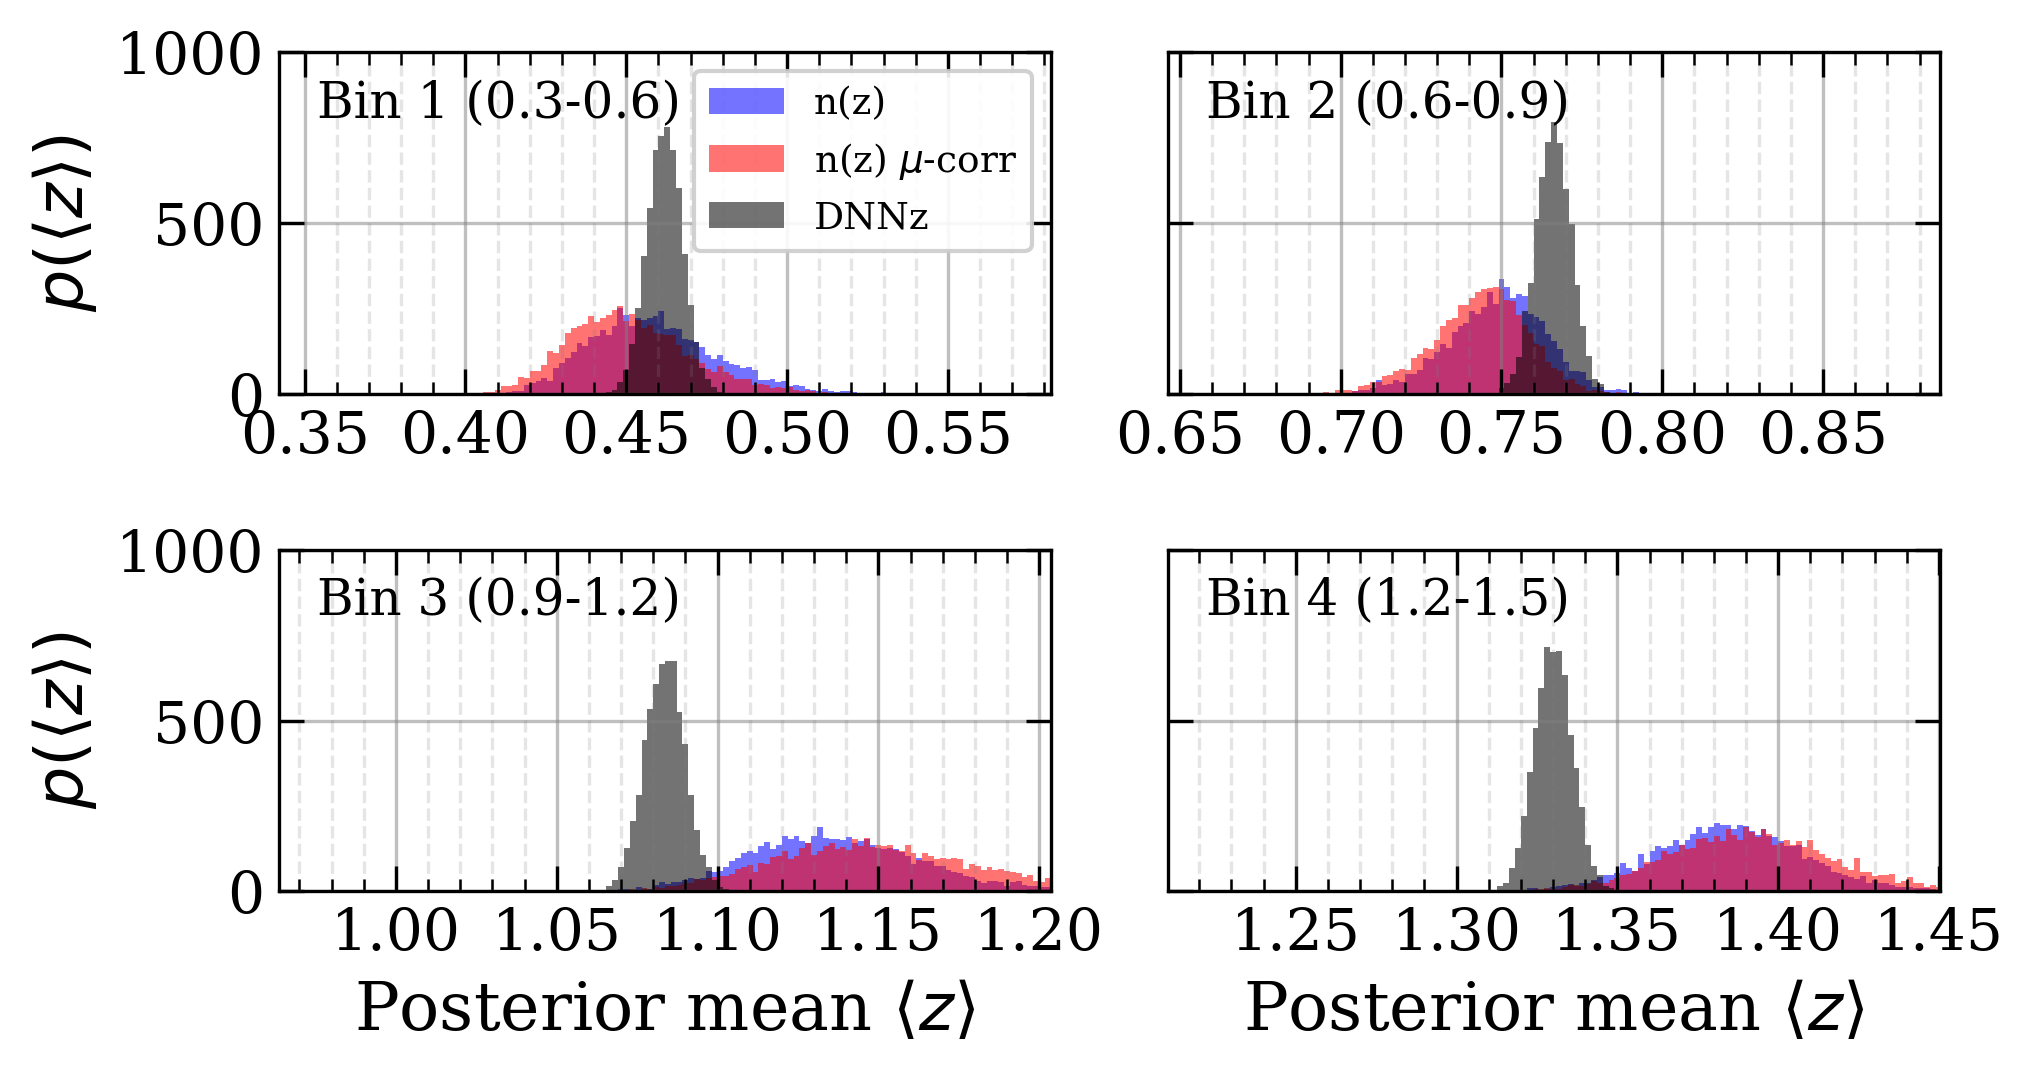

In [23]:
bounds = {
    '1' : (0, 0.9),
    '2' : (0.3, 1.3),
    '3' : (0.5, 2.1),
    '4' : (0.7, 2.1)
}
do_bounds = False
if not do_bounds:
    bounds = {
        f'{i}' : (0, 3) for i in range(1, 5)
    }

with pm.make_plot(name=f'posterior_means', show=True, figsize=(7, 3.8), nrows=2, ncols=2, sharey=True) as (fig, axs):
    bins_expect = np.linspace(0., 2, 1101)
    axs = axs.flatten()
    
    # draw samples from each and place on a histogram the expectation values
    for ax_i, spl in enumerate(splines_tomo_raw):
        z_eval = np.linspace(spl.zv.min(), spl.zv.max(), 200)
        mask = (z_eval > bounds[str(ax_i + 1)][0]) & (z_eval < bounds[str(ax_i + 1)][1])

        basis_eval = spl._create_evaluation_basis(z_eval)
        coeffs_samples = spl.coeffs_samples

        amplitude_samples = spl.amplitude_samples
        nz_samples = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]
        expect = [np.trapezoid(np.multiply(nzs[mask]/np.trapezoid(nzs[mask], z_eval[mask]), z_eval[mask]), z_eval[mask]) for nzs in nz_samples]
        axs[ax_i].hist(expect, bins=bins_expect, color='blue', alpha=0.55, label='n(z)' if ax_i == 0 else None)
        
        p16, p50, p84 = np.percentile(expect, [16, 50, 84])
        err_minus = p50 - p16
        err_plus  = p84 - p50
        print(f'Bin {ax_i+1} [n(z)]: 16th={p16:.3f}, median={p50:.3f}, 84th={p84:.3f} : {p50:.3f} (+{err_plus:.3f}, -{err_minus:.3f})')

    for ax_i, spl in enumerate(splines_tomo_mag):
        z_eval = np.linspace(spl.zv.min(), spl.zv.max(), 200)
        mask = (z_eval > bounds[str(ax_i + 1)][0]) & (z_eval < bounds[str(ax_i + 1)][1])

        basis_eval = spl._create_evaluation_basis(z_eval)
        coeffs_samples = spl.coeffs_samples

        amplitude_samples = spl.amplitude_samples
        nz_samples = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]
        expect = [np.trapezoid(np.multiply(nzs[mask]/np.trapezoid(nzs[mask], z_eval[mask]), z_eval[mask]), z_eval[mask]) for nzs in nz_samples]
        axs[ax_i].hist(expect, bins=bins_expect, color='red', alpha=0.55, label='n(z) ' + r'$\mu$' + '-corr' if ax_i == 0 else None)
        
        p16, p50, p84 = np.percentile(expect, [16, 50, 84])
        err_minus = p50 - p16
        err_plus  = p84 - p50
        print(f'Bin {ax_i+1} [n(z) ' + r'$\mu$' + f'-corr]: 16th={p16:.4f}, median={p50:.4f}, 84th={p84:.4f} : {p50:.3f} (+{err_plus:.3f}, -{err_minus:.3f})')

    for ax_i in range(len(axs)):
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, ax_i+1], mids, num_samples=6000)
        expect = [np.trapezoid(np.multiply(d/np.trapezoid(d, mids), mids), mids) for d in dnnz]
        axs[ax_i].hist(expect, bins=bins_expect, color='black', alpha=0.55, label='DNNz' if ax_i == 0 else None)
        
        axs[ax_i].text(
            0.05, 0.92,
            f'Bin {ax_i+1} ({0.3*(ax_i+1):.1f}-{0.3*(ax_i+2):.1f})',
            ha='left', va='top',
            transform=axs[ax_i].transAxes,
            fontsize=12,
        )
        # for each plot, add a .05 grid in xticks
        axs[ax_i].set_xticks(np.arange(0.2, 1.6, 0.05))
        # add a subgridding of 0.01, without showing the ticks but only for the grid
        axs[ax_i].set_xticks(np.arange(0.2, 1.6, 0.01), minor=True)
        axs[ax_i].grid(True, which='major', color='gray', alpha=0.5)
        axs[ax_i].grid(True, which='minor', color='gray', alpha=0.2, linestyle='--')
        
        p16, p50, p84 = np.percentile(expect, [16, 50, 84])
        err_minus = p50 - p16
        err_plus  = p84 - p50
        print(f'Bin {ax_i+1} [n(z) DNNz]: 16th={p16:.4f}, median={p50:.4f}, 84th={p84:.4f} : {p50:.3f} (+{err_plus:.3f}, -{err_minus:.3f})')
        
        axs[ax_i].set_xlim(np.mean(expect)-0.12, np.mean(expect)+0.12)
        axs[ax_i].set_ylim(0, 1000)
        if ax_i == 0:
            axs[ax_i].legend(fontsize=9, loc='upper right', framealpha=0.9)
        if ax_i == 0 or ax_i == 2: 
            axs[ax_i].set_ylabel(r'$p(\langle z\rangle)$')
        if ax_i == 2 or ax_i == 3:
            axs[ax_i].set_xlabel(f'Posterior mean ' +r'$\langle z \rangle$')

Bin 1 [n(z)]: 16th=0.415, median=0.424, 84th=0.434 : 0.424 (+0.009, -0.009)
Bin 2 [n(z)]: 16th=0.752, median=0.759, 84th=0.767 : 0.759 (+0.008, -0.007)
Bin 3 [n(z)]: 16th=1.099, median=1.118, 84th=1.140 : 1.118 (+0.022, -0.020)
Bin 4 [n(z)]: 16th=1.365, median=1.377, 84th=1.391 : 1.377 (+0.014, -0.012)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4116, median=0.4208, 84th=0.4296 : 0.421 (+0.009, -0.009)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7471, median=0.7545, 84th=0.7623 : 0.755 (+0.008, -0.007)
Bin 3 [n(z) $\mu$-corr]: 16th=1.0986, median=1.1215, 84th=1.1455 : 1.121 (+0.024, -0.023)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3650, median=1.3789, 84th=1.3935 : 1.379 (+0.015, -0.014)
Bin 1 [n(z) DNNz]: 16th=0.4563, median=0.4618, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7608, median=0.7662, 84th=0.7715 : 0.766 (+0.005, -0.005)
Bin 3 [n(z) DNNz]: 16th=1.0772, median=1.0835, 84th=1.0899 : 1.083 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3242, median=1.3300, 84th=1.3359 : 1.330 (+0.006, -0.006) 
with bounds

without bounds :
Bin 1 [n(z)]: 16th=0.439, median=0.457, 84th=0.479 : 0.457 (+0.022, -0.018)
Bin 2 [n(z)]: 16th=0.734, median=0.750, 84th=0.763 : 0.750 (+0.014, -0.016)
Bin 3 [n(z)]: 16th=1.110, median=1.135, 84th=1.164 : 1.135 (+0.029, -0.025)
Bin 4 [n(z)]: 16th=1.362, median=1.385, 84th=1.407 : 1.385 (+0.022, -0.023)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4325, median=0.4493, 84th=0.4698 : 0.449 (+0.021, -0.017)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7287, median=0.7442, 84th=0.7576 : 0.744 (+0.013, -0.016)
Bin 3 [n(z) $\mu$-corr]: 16th=1.1172, median=1.1471, 84th=1.1817 : 1.147 (+0.035, -0.030)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3661, median=1.3910, 84th=1.4173 : 1.391 (+0.026, -0.025)
Bin 1 [n(z) DNNz]: 16th=0.4565, median=0.4619, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7607, median=0.7663, 84th=0.7718 : 0.766 (+0.006, -0.006)
Bin 3 [n(z) DNNz]: 16th=1.0773, median=1.0836, 84th=1.0898 : 1.084 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3243, median=1.3301, 84th=1.3361 : 1.330 (+0.006, -0.006)

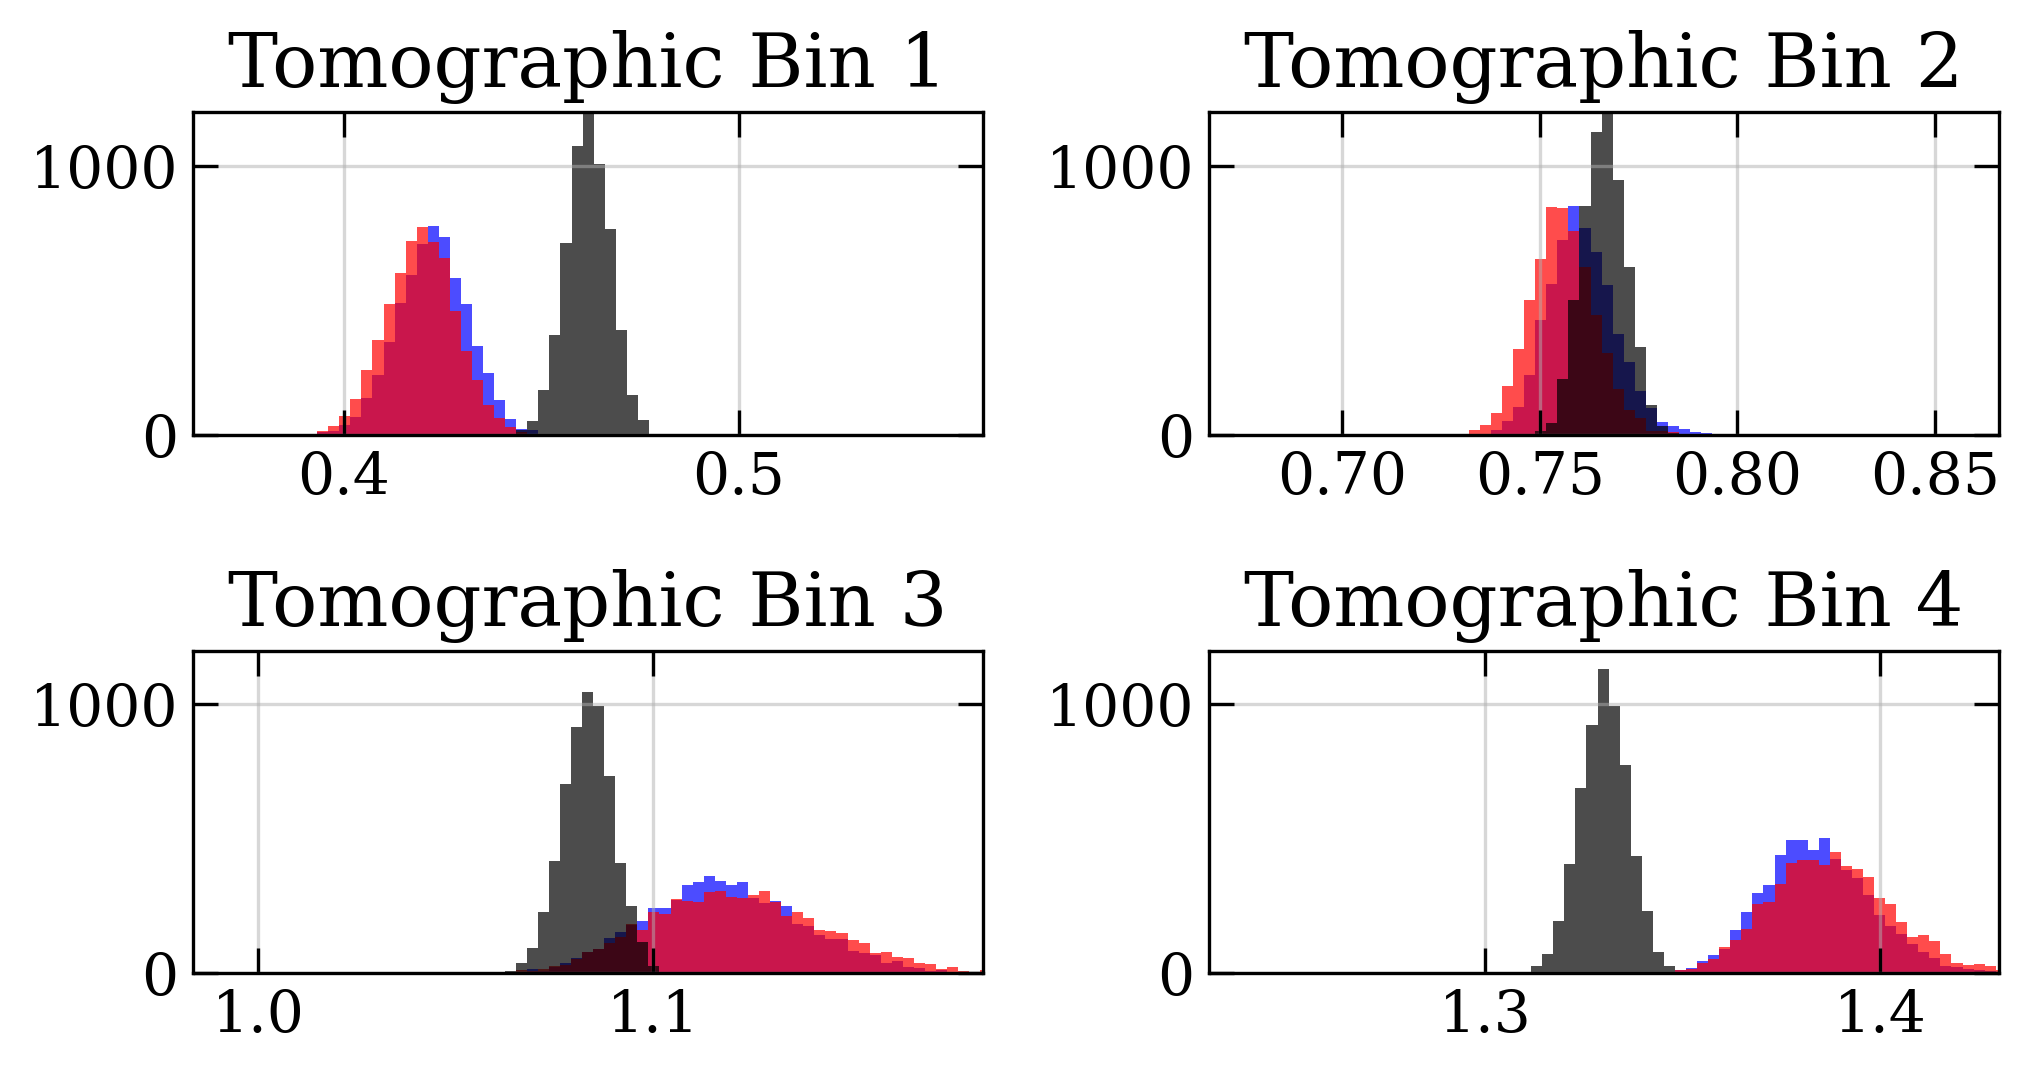

In [13]:
%pip install dill
import dill
save_splines = Path('splines')
save_splines.mkdir(exist_ok=True)
with open(save_splines / f'spline_raw_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_raw_1, f)
with open(save_splines / f'spline_mag_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_mag_1, f)

Note: you may need to restart the kernel to use updated packages.
